# Análisis Exploratorio y Curación de Datos
> Estimación de precios de propiedades de Melbourne

## Ejercicio 2 - Pandas 

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar las columnas seleccionadas y las que no lo fueron.
> Ver [Columnas de interés](#Columnas-de-interés)  
> NOTA: Se realizó la combinación del dataset propuesta en el inciso 4 del ejercicio 1 en esta instancia.
- Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
> El procedimiento *natural* es tratar los datos faltantes (nan) y luego los outliers.  
> Ver [Eliminación de filas](#Eliminación-de-filas)  
> Ver [Outliers](#Outliers) *(no hay)*  
> NOTA: Se realizó la limpieza, formateo, normalización de datos y eliminación de outliers con los datasets combinados según lo propuesto en el ejercicio 2.

2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico. 
> Combinar datasets luego de realizar los esfuerzos de limpieza, formateo y eliminación de filas resulta en un dataset de mala calidad, por lo que se decidió realizar este punto durante la elección de columnas de interés.  
> Ver [Combinar datasets](#Combinar-datasets)
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana o el mínimo.
> Ver [Columnas de interés del entorno](#Columnas-de-interés-del-entorno)
  1. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
> Se requiere pre-procesamiento del dataset de airbnb, dado que introduce datos faltantes, inválidos, filas repetidas, etc: ver [procesamiento](#Procesamiento-previo-de-dataset-a-combinar)
> *(numeración de la consigna repetida)* `zipcode` **NO SE ENCUENTRA EN EL DATASET INICIAL**, esto seguramente se debe a la desorganización en la confección de la consigna y poca coherencia y uniformidad de los recursos a usar.
  2. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
> Ver [Criterios de unión](#Criterios-de-unión)

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.
> ¿Dónde está `interesting_cols`? 



## Ejercicio 3

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.
> ver [Exportación de datos](#Exportación-de-datos)

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pandas.api.types import CategoricalDtype

/home/ruben/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
FIGSIZE, VSUBPLOTS_FIGSIZE, HSUBPLOTS_FIGSIZE, DPI = (10, 5), (15, 10), (15, 5), 100
PASTEL_PALETTE = sns.color_palette('pastel')
MAIN_PALETTE = itertools.cycle(PASTEL_PALETTE)
CATEGORICAL_PALETTE = sns.color_palette('Set2')
SECUENTIAL_PALETTE = sns.color_palette('flare')

statistics_of_interest = ['mean', 'std', '25%', '50%', '75%']

In [3]:
def human_format(num, pos=1):
    """
    human formatting for big numbers
    """
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return "%.0f%s" % (num, ["", "K", "M", "G", "T", "P"][magnitude])


FORMATTER = FuncFormatter(human_format)

In [4]:
def plot_hist(df_to_plot, x_label, y_label, title, n_bins=100):
    f, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI, sharex=True)

    sns.histplot(df_to_plot,
                 bins=n_bins,
                 color=next(MAIN_PALETTE),
                 kde=True)

    ax = plt.gca()
    ax.figsize=FIGSIZE

    statistics = df_to_plot.describe(include='all')

    for j, name in enumerate(['mean', 'std']):
        linestyle = 'solid' if name == 'mean' else 'dashed'
        alpha = 1 if name == 'mean' else .6

        statistic = statistics[name]

        ax.axvline(statistic,
                  label=f'{name}: {human_format(statistic)}',
                  color=CATEGORICAL_PALETTE.as_hex()[-j],
                  linestyle=linestyle,
                  alpha=alpha)

        for j, st in enumerate(['25%', '50%', '75%']):
            statistic = statistics[st]
            ax.axvline(statistic,
                      label=f'{st}: {human_format(statistic)}',
                      color=SECUENTIAL_PALETTE.as_hex()[j],
                      linestyle='dashed',
                      alpha=.6,)

        ax.xaxis.set_major_formatter(FORMATTER)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.xlim(-0.5 * statistics['std'], 7 * statistics['std'])
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()

In [5]:
melbourne_data_url = 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv'

df = pd.read_csv(melbourne_data_url)
#df = pd.read_csv('data/melb_data.csv')
df.head(10).style.format(
    {'Price': human_format,},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingArea'], color='brown')

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1M,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,missing,missing,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1M,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1M,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850K,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,missing,missing,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,2M,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
5,Abbotsford,129 Charles St,2,h,941K,S,Jellis,7/05/2016,2.5,3067.0,2.0,1.0,0.0,181.0,missing,missing,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,2M,S,Nelson,7/05/2016,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2,h,2M,S,Nelson,8/10/2016,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
8,Abbotsford,6/241 Nicholson St,1,u,300K,S,Biggin,8/10/2016,2.5,3067.0,1.0,1.0,1.0,0.0,missing,missing,Yarra,-37.8,145.0,Northern Metropolitan,4019.0
9,Abbotsford,10 Valiant St,2,h,1M,S,Biggin,8/10/2016,2.5,3067.0,3.0,1.0,2.0,220.0,75.0,1900.0,Yarra,-37.8,145.0,Northern Metropolitan,4019.0


In [6]:
df.describe().style.format(
    {col: human_format for col in ['Price', 'Landsize', 'BuildingArea', 'Propertycount']},
    precision=1,
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingArea', 'Landsize'], color='brown')

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.0,14K,13580.0,13580.0,13580.0,13580.0,13518.0,14K,7K,8205.0,13580.0,13580.0,14K
mean,2.9,1M,10.1,3105.3,2.9,1.5,1.6,558,152,1964.7,-37.8,145.0,7K
std,1.0,639K,5.9,90.7,1.0,0.7,1.0,4K,541,37.3,0.1,0.1,4K
min,1.0,85K,0.0,3000.0,0.0,0.0,0.0,0,0,1196.0,-38.2,144.4,249
25%,2.0,650K,6.1,3044.0,2.0,1.0,1.0,177,93,1940.0,-37.9,144.9,4K
50%,3.0,903K,9.2,3084.0,3.0,1.0,2.0,440,126,1970.0,-37.8,145.0,7K
75%,3.0,1M,13.0,3148.0,3.0,2.0,2.0,651,174,1999.0,-37.8,145.1,10K
max,10.0,9M,48.1,3977.0,20.0,8.0,10.0,433K,45K,2018.0,-37.4,145.5,22K


| Column | Description | Type |
|---|---|---|
| Suburb | Self explanitory | str |
| Address | Self explanitory | str |
| Rooms | Number of rooms | int |
| Price | Price in Australian dollars | float |
| Method | S - property sold;   SP - property sold prior;   PI - property passed in;   PN - sold prior not disclosed;   SN - sold not disclosed;   NB - no bid;   VB - vendor bid;   W - withdrawn prior to auction;   SA - sold after auction;   SS - sold after auction price not disclosed.   N/A - price or highest bid not available.   | str (should be cat) |
| Type | br - bedroom(s);   h - house,cottage,villa, semi,terrace;   u - unit, duplex;   t - townhouse;   dev site - development site;   o res - other residential.   | str (should be cat) |
| SellerG | Real Estate Agent | str |
| Date | Date sold | str (should be datetime) |
| Distance | Distance from CBD in Kilometres | float |
| Regionname | General Region (West, North West, North, North east …etc) | str (should be cat) |
| Propertycount | Number of properties that exist in the suburb. | int |
| Bedroom2 | Scraped # of Bedrooms (from different source) | int |
| Bathroom | Number of Bathrooms | int |
| Car | Number of carspots | int |
| Landsize | Land Size in Metres | float |
| BuildingArea | Building Size in Metres | float |
| YearBuilt | Year the house was built | int |
| CouncilArea | Governing council for the area | str (should be cat) |
| Lattitude | Self explanitory | float |
| Longtitude | Self explanitory | float |

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

### histograma precios exploratorio

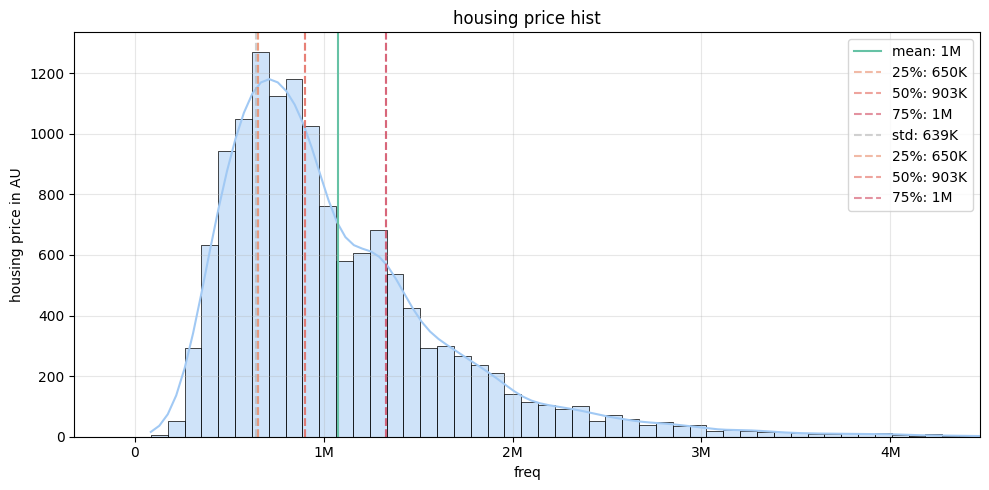

In [8]:
df_to_plot = df.Price
x_label, y_label, title = 'freq', 'housing price in AU', 'housing price hist'

plot_hist(df_to_plot, x_label, y_label, title)

### Columnas de interés

Se seleccionó el siguiente subconjunto de columnas:
- `Address`: si bien se considera a `Suburb` como categoría de agrupamiento relacionada a la ubicación, es necesaria para procesos porteriores.
- `Suburb`: se encuentra normalizada y se presume que tiene correlación con el precio de la propiedad.
- `Rooms`: se sabe que la cantidad de habitaciones de un inmueble se relaciona de manera directamente proporcional con su precio.
- `Price`: es la columna protagonista del análisis.
- `Type`: se estima que actúa a modo de categoría de las propiedades y *podría* inferir en el precio.
- `Distance`: se sabe que los puntos de interés cercanos a una vivienda aumentan su valor.
- `Propertycount`: la densidad habitacional de la zona *podría* inferir en el precio.
- `Bedroom2`: información extra sobre cantidad de dormitorios.
- `Car`: las "amenities" influyen en el precio.
- `Landsize`: el área en la que se encuentra la propiedad es de importancia para definir su precio.
- `BuildingArea`: se puede trabajar en conjunto con la columna anterior para definir el ratio de construcción.
- `YearBuilt`: la antigüedad resulta importante en el precio.

Mientras que se descartan las siguientes:
- `Method`: para este análisis no se tuvo en cuenta esta columna por falta de conocimiento de estimar cómo influyen las características específicas de real state.
- `SellerG`: no se tuvo en cuenta esta columna por falta de conocimiento de estimar cómo influyen las características específicas de real state.
- `Date`: no se consideró el estado de venta de la propiedad en este análisis a fin de simplificarlo.
- `Regionname`: se descartó al tomar `Suburb` como categoría de agrupamiento relacionada a la ubicación.
- `CouncilArea`: se descartó al tomar `Suburb` como categoría de agrupamiento relacionada a la ubicación.
- `Latitude`: Se descartó al tomar `Suburb` como categoría de agrupamiento relacionada a la ubicación.
- `Longitude`: Se descarta al tomar `Suburb` como categoría de agrupamiento relacionada a la ubicación.

In [9]:
columns_of_interest = ['Address', 'Suburb', 'Rooms', 'Price', 'Type', 'Distance',
                       'Propertycount', 'Bedroom2', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']

df = df[columns_of_interest]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Address        13580 non-null  object 
 1   Suburb         13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Price          13580 non-null  float64
 4   Type           13580 non-null  object 
 5   Distance       13580 non-null  float64
 6   Propertycount  13580 non-null  float64
 7   Bedroom2       13580 non-null  float64
 8   Car            13518 non-null  float64
 9   Landsize       13580 non-null  float64
 10  BuildingArea   7130 non-null   float64
 11  YearBuilt      8205 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 1.2+ MB


### Combinar datasets

> Este procedimiento corresponde al **ejercicio 1 - inciso 4**. Se realizó en esta instancia debido a que, al llegar al ejercicio en cuestión y combinar datasets, se deshicieron todos los esfuerzos de limpiar los datos, formatearlos, eliminar filas y detectar outliers, resultando en un dataset de muy mala calidad.

> No es posible leer la data directamente desde la URL proporcionada

In [11]:
df_airbnb = pd.read_csv('data/cleansed_listings_dec18.csv')
df_airbnb.head()

/tmp/ipykernel_5304/3701311982.py:1: DtypeWarning: Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df_airbnb = pd.read_csv('data/cleansed_listings_dec18.csv')


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,neighborhood_overview,notes,...,review_scores_location,review_scores_value,requires_license,license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,9835,https://www.airbnb.com/rooms/9835,2.018120e+13,12/7/2018,Beautiful Room & House,NaN,"House: Clean, New, Modern, Quite, Safe. 10Km f...","House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,NaN,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,1,0.04
1,10803,https://www.airbnb.com/rooms/10803,2.018120e+13,12/7/2018,Room in Cool Deco Apartment in Brunswick,A large air conditioned room with queen spring...,The apartment is Deco/Edwardian in style and h...,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,NaN,...,9.0,9.0,f,NaN,t,moderate,t,t,1,1.50
2,12936,https://www.airbnb.com/rooms/12936,2.018120e+13,12/7/2018,St Kilda 1BR APT+BEACHSIDE+VIEWS+PARKING+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,FREE WiFi FREE in-building remote controlled g...,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,First floor apartment with both lift and stair...,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,17,0.15
3,15246,https://www.airbnb.com/rooms/15246,2.018120e+13,12/7/2018,Large private room-close to city,"Comfortable, relaxed house, a home away from ...",The atmosphere is relaxed and easy going. You ...,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...",A simple self service breakfast is available –...,...,9.0,9.0,f,NaN,f,moderate,f,f,3,0.30
4,16760,https://www.airbnb.com/rooms/16760,2.018120e+13,12/7/2018,Melbourne BnB near City & Sports,NaN,We offer comfortable accommodation in Inner Me...,We offer comfortable accommodation in Inner Me...,NaN,NaN,...,10.0,9.0,f,NaN,f,moderate,f,f,1,0.74


In [12]:
df_airbnb.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'neighborhood_overview', 'notes', 'transit',
       'access', 'interaction', 'house_rules', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighborhood',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'price',
       'weekly_price', 'monthly_price', 'security_deposit', 'cleaning_fee',
       'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights',
       'calendar_updated', 

In [13]:
df_airbnb.size

1923180

#### Columnas de interés del entorno

Las columnas con información relacionada a al entorno son:
- `neighborhood_overview`,  
    - se agrega aunque es no es uniforme, ni agrupable
- `street`,
    - *(alternativa para combinar datasets)*, información redundante, no se tiene en cuenta
- `neighborhood`,  
- `city`,
- `suburb`,
    - columna que se emplea para relacionar los datasets
- `state`,  
- `zipcode`,  
- `smart_location`,    
- `country_code`,  
    - información redundante (todas las propiedades pertenecen a Australia), no se tiene en cuenta
- `country`  
    - información redundante (todas las propiedades pertenecen a Australia), no se tiene en cuenta

In [14]:
df_airbnb = df_airbnb[['neighborhood_overview', 'neighborhood', 'suburb', 'city', 'state', 'zipcode', 'smart_location']]
df_airbnb = df_airbnb.rename(columns={
    'neighborhood_overview': 'NeighborhoodOverview',
    'neighborhood': 'Neighborhood',
    'suburb': 'Suburb',
    'city': 'City',
    'state': 'State',
    'zipcode': 'ZipCode',
    'smart_location': 'SmartLocation'
})

In [15]:
df_airbnb.head()

,NeighborhoodOverview,Neighborhood,Suburb,City,State,ZipCode,SmartLocation
0,Very safe! Family oriented. Older age group.,Balwyn North,Bulleen,Manningham,VIC,3105,"Bulleen, Australia"
1,This hip area is a crossroads between two grea...,Brunswick,Brunswick East,Moreland,VIC,3057,"Brunswick East, Australia"
2,A stay at our apartment means you can enjoy so...,St Kilda,St Kilda,Port Phillip,VIC,3182,"St Kilda, Australia"
3,"This is a great neighbourhood – it is quiet, y...",Thornbury,Thornbury,Darebin,VIC,3071,"Thornbury, Australia"
4,NaN,St Kilda East,St Kilda East,Port Phillip,VIC,3183,"St Kilda East, Australia"


##### Procesamiento previo de dataset a combinar

El join propuesto es completamente arbitrario:

- La información que se busca agregar sobre el entorno es imprecisa *(dado que airbnb no provee datos exactos sobre ubicación de propiedad por razones de seguridad)*, esto resulta en filas con mismo `Address` y diferente neighborhood,
    - *Al menos* **20mil** valores faltantes por columna.
    - En la columna `City` algunos nombres no corresponden a ciudades, entre otras inconsistencias.
    - La columna `State` no esa normalizada, no provee información sobre estados que no sean Victoria, por lo que podría resultar en un análisis del modelo sesgado.
        - Se normaliza 
    - La columna `Suburb` tiene valores faltantes e inválidos, al ser la columna de criterio de unión, esto trae problemas.
        - Se eliminan las filas con suburbios inválidos.
    - `SmartLocation` no aporta información en absoluto, dado que ya se cuenta con `Address`
    - `ZipCode` contiene muchos valores faltantes, una mejor alternativa sería conseguirlos con una API de geo o similar
    - `NeighborhoodOverview` podría resultar en información al menos interesante para predicción de precios, pero requiere un proceso dedicado sólo a esta fila de normalización, extracción de palabras clave, NLP, etc.
        - Se agrupan en una solo str las overview por vecindario

###### Normalización de la columns State

In [16]:
df_airbnb.State.unique()

array(['VIC', 'Victoria', 'Vic', 'vic', 'Melbourne', '维多利亚州', nan,
       'VICTORIA', '维多利亚', 'Australia', 'victoria', '維多利亞 VIC',
       'Melbourne, Victoria', 'Melbourne VIC 3000',
       'Wheelers Hill VIC 3150', 'South Yarra VIC 3141', 'NSW',
       'Doncaster VIC 3108', 'Somerton VIC 3062', 'Brunswick VIC 3056',
       'Wantirna South VIC 3152', 'Melbourne VIC 3004', 'VI', 'VICtoria',
       'VIC 3008', 'Victory', 'QLD', 'Mel'], dtype=object)

In [18]:
def norm_state(state):
    """
    The 8 states of AU are:
        New South Wales. (NSW)
        Northern Territory.
        Queensland.
        South Australia.
        Tasmania.
        Victoria. (VIC)
        Western Australia.
    """
    vic_variables = ['VIC', 'Victoria', 'Vic', 'vic',
                     'VICTORIA', 'Victory', 'victoria',
                     'VI', 'VIC 3008', 'VICtoria']
    if state in vic_variables:
        return 'VIC'
    if state == 'NSW':
        return 'NSW'
    else:
        return np.nan

In [19]:
df_airbnb.State = df_airbnb.State.apply(norm_state)
df_airbnb.State

0        VIC
1        VIC
2        VIC
3        VIC
4        VIC
        ... 
22890    VIC
22891    VIC
22892    VIC
22893    VIC
22894    VIC
Name: State, Length: 22895, dtype: object

###### Drop Suburb inválido

In [20]:
df_airbnb.Suburb = df_airbnb.Suburb.apply(lambda x: np.nan if x not in df.Suburb.unique() else x)
df_airbnb = df_airbnb.dropna(subset=['Suburb'])

###### Agrupamiento de NeighborhoodOverview

In [21]:
grouped_overviews = df_airbnb.groupby('Neighborhood')['NeighborhoodOverview'].apply(lambda x: '; '.join([
    overview for overview in x if isinstance(overview, str)]))
grouped_overviews = grouped_overviews.to_frame()
grouped_overviews

,NeighborhoodOverview
Neighborhood,
Abbotsford,I love Abbotsford for its mix of local charact...
Albert Park,A quiet street in leafy Albert Park midway bet...
Alphington,"The immediate neighbourhood is very peaceful, ..."
Armadale,"This is close to everything in Melbourne, shop..."
Ashburton,Our local parks and gardens provide lovely wal...
Balaclava/Ripponlea,BALACLAVA/ST. KILDA EAST (same area) Originall...
Balwyn,"Balwyn is a family suburb east of Melbourne, a..."
Balwyn North,Very safe! Family oriented. Older age group.; ...
Bentleigh,Oakleigh is a vibrant Greek community with lot...


In [22]:
df_airbnb = df_airbnb.drop(columns=['NeighborhoodOverview'])
df_airbnb = df_airbnb.drop_duplicates()

In [23]:
df_airbnb.columns

Index(['Neighborhood', 'Suburb', 'City', 'State', 'ZipCode', 'SmartLocation'], dtype='object')

In [24]:
df_airbnb = df_airbnb.merge(grouped_overviews, left_on='Neighborhood', right_on='Neighborhood')
df_airbnb = df_airbnb.drop_duplicates()

In [25]:
df_airbnb.sample(20)

,Neighborhood,Suburb,City,State,ZipCode,SmartLocation,NeighborhoodOverview
161,Port Melbourne,Melbourne,Port Phillip,VIC,3207.0,"Melbourne, Australia",Port Melbourne is one of Melbourne's most soug...
240,Carlton,Melbourne,Melbourne,VIC,3000,"Melbourne, Australia","Carlton is a buzzing area, full of culture, cu..."
128,Fitzroy,Collingwood,Yarra,VIC,3066,"Collingwood, Australia","One of Melbourne's smallest urban areas, Fitzr..."
374,Balaclava/Ripponlea,Balaclava,Port Phillip,VIC,3183,"Balaclava, Australia",BALACLAVA/ST. KILDA EAST (same area) Originall...
195,South Yarra,Melbourne,Port Phillip,VIC,3004.0,"Melbourne, Australia",South Yarra is a blend of fast and slow. The s...
74,Richmond,Richmond,Yarra,VIC,3121.0,"Richmond , Australia",Bridge Road (once famous for discount shopping...
449,Preston,Heidelberg West,Banyule,VIC,3081,"Heidelberg West, Australia",Preston is a great place and an upcoming subur...
320,Collingwood,Clifton Hill,Yarra,VIC,3068,"Clifton Hill, Australia","Close to smith street, the MCG, Melbourne Park..."
313,Albert Park,South Melbourne,Port Phillip,VIC,3205,"South Melbourne, Australia",A quiet street in leafy Albert Park midway bet...
287,Coburg,Pascoe Vale,Moreland,VIC,3044.0,"Pascoe Vale, Australia",The apartment is fully self contained and sepa...


> Neighborhood > Suburb???

#### Criterios de unión

> El criterio sugerido no pudo llevarse a cabo dado que **zipcode NO SE ENCUENTRA EN EL DATASET PROVISTO**

Se establece a continuación otros criterios de unión.

- Los datasets de interés comparten la columna `Suburb`, la que se emplea para *"mergear"* los datos.
- Se agrega como criterio alternativo el campo `Street`, para implementar se debe proceder como sigue:
    - Crear una nueva columna a partir de `Address` en el dataframe original, `df['Street'] = df.Address.apply(lambda x: x.split(' ')[1])`
    - Y otra en el dataframe de airbnb: `df_airbnb['JustStreet'] = df_airbnb.Street.apply(lambda x: x.split(', ')[0].replace('St', '').strip().capitalize())`
    - Se tiene entonces una equivalencia de calles normalizadas y capitalizadas.
    - Mergear así los datos con el criterio en cuestión: `df = pd.merge(df, df_airbnb, left_on='Street', right_on='JustStreet')`

In [26]:
common_suburbs = set(df.Suburb.unique()).intersection(df_airbnb.Suburb.unique())
len(common_suburbs)

112

In [27]:
df_merged = df.merge(df_airbnb, left_on='Suburb', right_on='Suburb')
df_merged.head()

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,Landsize,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview
0,85 Turner St,Abbotsford,2,1480000.0,h,2.5,4019.0,2.0,1.0,202.0,NaN,NaN,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...
1,85 Turner St,Abbotsford,2,1480000.0,h,2.5,4019.0,2.0,1.0,202.0,NaN,NaN,Kew,Boroondara,VIC,3067.0,"Abbotsford, Australia",It is walking distance to the Kew Junction sho...
2,85 Turner St,Abbotsford,2,1480000.0,h,2.5,4019.0,2.0,1.0,202.0,NaN,NaN,Abbotsford,Yarra,VIC,3067,"Abbotsford, Australia",I love Abbotsford for its mix of local charact...
3,85 Turner St,Abbotsford,2,1480000.0,h,2.5,4019.0,2.0,1.0,202.0,NaN,NaN,Abbotsford,Yarra,VIC,3067.0,"Abbotsford, Australia",I love Abbotsford for its mix of local charact...
4,85 Turner St,Abbotsford,2,1480000.0,h,2.5,4019.0,2.0,1.0,202.0,NaN,NaN,Abbotsford,Yarra,VIC,NaN,"Abbotsford, Australia",I love Abbotsford for its mix of local charact...


> La combinación arbitraria propuesta genera filas repetidas

In [28]:
df_merged.columns

Index(['Address', 'Suburb', 'Rooms', 'Price', 'Type', 'Distance',
       'Propertycount', 'Bedroom2', 'Car', 'Landsize', 'BuildingArea',
       'YearBuilt', 'Neighborhood', 'City', 'State', 'ZipCode',
       'SmartLocation', 'NeighborhoodOverview'],
      dtype='object')

In [29]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53631 entries, 0 to 53630
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Address               53631 non-null  object 
 1   Suburb                53631 non-null  object 
 2   Rooms                 53631 non-null  int64  
 3   Price                 53631 non-null  float64
 4   Type                  53631 non-null  object 
 5   Distance              53631 non-null  float64
 6   Propertycount         53631 non-null  float64
 7   Bedroom2              53631 non-null  float64
 8   Car                   53223 non-null  float64
 9   Landsize              53631 non-null  float64
 10  BuildingArea          29027 non-null  float64
 11  YearBuilt             34168 non-null  float64
 12  Neighborhood          53631 non-null  object 
 13  City                  53631 non-null  object 
 14  State                 51380 non-null  object 
 15  ZipCode            

In [30]:
df_merged.size

965358

In [31]:
df_merged = df_merged.drop_duplicates(subset=['Address', 'Rooms', 'Price'])
df_merged.size

176688

In [32]:
df = df_merged 
df_merged.columns

Index(['Address', 'Suburb', 'Rooms', 'Price', 'Type', 'Distance',
       'Propertycount', 'Bedroom2', 'Car', 'Landsize', 'BuildingArea',
       'YearBuilt', 'Neighborhood', 'City', 'State', 'ZipCode',
       'SmartLocation', 'NeighborhoodOverview'],
      dtype='object')

In [33]:
df.sample(10).style.format(
    {'Price': human_format,
    'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,Landsize,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview
38759,4 Newton St,Reservoir,3,800K,h,12.0,21650.0,3.0,2.0,585.0,90.0,1960.0,Coburg,Darebin,VIC,3073,"Reservoir, Australia",The apartment is fully self contained and separate
1337,31A Sutherland Rd,Armadale,3,2M,h,6.3,4836.0,3.0,2.0,348.0,missing,1952.0,Prahran,Stonnington,VIC,3143,"Armadale, Australia",Prahran is a great place to live. There are nice p
33382,5 Virginia St,Pascoe Vale,3,600K,h,9.9,7485.0,3.0,4.0,557.0,111.0,1955.0,Coburg,Moreland,VIC,3044,"Pascoe Vale, Australia",The apartment is fully self contained and separate
45647,26 Nelson St,St Kilda,2,808K,h,6.1,13240.0,2.0,0.0,124.0,missing,1908.0,St Kilda,Port Phillip,VIC,3182,"St Kilda, Australia",A stay at our apartment means you can enjoy some o
12508,18 Derby St,Collingwood,2,1M,h,1.6,4553.0,2.0,2.0,116.0,missing,missing,Fitzroy,Yarra,VIC,3066,"Collingwood, Australia","One of Melbourne's smallest urban areas, Fitzroy,"
40763,712/8 Howard St,Richmond,2,927K,u,2.4,14949.0,2.0,2.0,0.0,missing,2000.0,Richmond,Yarra,VIC,3121,"Richmond, Australia","Bridge Road (once famous for discount shopping, no"
11063,9/400 Dandenong Rd,Caulfield North,2,420K,u,8.1,6923.0,2.0,1.0,0.0,56.0,2012.0,St Kilda,Port Phillip,VIC,3161.0,"Caulfield North, Australia",A stay at our apartment means you can enjoy some o
7194,4 Bryant St,Brunswick,4,820K,h,5.2,11918.0,3.0,0.0,416.0,missing,missing,Brunswick,Moreland,VIC,3056,"Brunswick, Australia",This hip area is a crossroads between two great cu
22608,25 Carlyle St,Maidstone,3,676K,h,9.2,3873.0,3.0,1.0,250.0,missing,missing,Footscray,Maribyrnong,VIC,3012,"Maidstone, Australia",Seddon is a great place and growing by the minute
49835,10 Harrison St,Brunswick East,3,1M,h,4.5,5533.0,3.0,2.0,456.0,144.0,1950.0,Brunswick,Moreland,VIC,3057,"Brunswick East, Australia",This hip area is a crossroads between two great cu


#### Building Ratio

A fin de concentrar la información provista en `Landsize` y `BuildingArea` se calcula el `BuildingRatio` dado por:  $\frac{Landsize}{BuildingArea}$

In [34]:
df.loc[:, 'BuildingRatio'] = df.loc[:, 'Landsize'] / df.loc[:, 'BuildingArea']
df.BuildingRatio.replace([np.inf, -np.inf], np.nan, inplace=True)

In [35]:
df = df.drop(columns=['Landsize'])  # BuildingArea es requerido para consignas posteriores

In [38]:
df.sample(15).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
29497,25 Argyle St,Moonee Ponds,2,750K,h,6.9,6232.0,2.0,1.0,missing,missing,Brunswick,Moonee Valley,VIC,3039,"Moonee Ponds, Australia",This hip area is a crossroads between two great cu,missing
11561,53 John St,Clifton Hill,2,640K,t,3.4,2954.0,2.0,1.0,missing,missing,Clifton Hill,Yarra,VIC,3068,"Clifton Hill, Australia",The neighborhood of Clifton Hill is very friendly,missing
51531,32 Murray St,Fawkner,2,950K,h,12.4,5070.0,2.0,1.0,missing,missing,Coburg,Moreland,VIC,3060.0,"Fawkner, Australia",The apartment is fully self contained and separate,missing
52174,200 Somerville Rd,Kingsville,3,760K,h,7.8,1808.0,3.0,1.0,114.0,1950.0,Yarraville/Seddon,Maribyrnong,VIC,3012,"Kingsville, Australia",The house is located in a quiet street in the hip,3.1
10272,700 Rathdowne St,Carlton North,4,2M,h,3.2,3106.0,3.0,0.0,163.0,1920.0,Carlton,Melbourne,VIC,3054.0,"Carlton North, Australia","Carlton is a buzzing area, full of culture, cuisin",2.6
17284,6 White St,Footscray,2,823K,h,6.4,7570.0,2.0,0.0,missing,missing,Yarraville/Seddon,Maribyrnong,VIC,3011,"Footscray, Australia",The house is located in a quiet street in the hip,missing
1457,75 Maribyrnong Rd,Ascot Vale,6,2M,h,5.9,6567.0,6.0,2.0,435.0,1887.0,Brunswick,Moonee Valley,VIC,3032,"Ascot Vale, Australia",This hip area is a crossroads between two great cu,2.3
8412,1/30 McLean St,Brunswick West,2,484K,u,5.9,7082.0,2.0,1.0,65.0,1950.0,Brunswick,Moreland,VIC,3055,"Brunswick West, Australia",This hip area is a crossroads between two great cu,0.0
4920,115 Dendy St,Brighton,4,3M,h,11.2,10579.0,4.0,6.0,missing,missing,Brighton,Bayside,VIC,3186,"Brighton, Australia",Very leafy very safe street 5 minute walk to 711 c,missing
357,104 Richardson St,Albert Park,4,2M,h,3.3,3280.0,4.0,1.0,180.0,1880.0,Middle Park,Port Phillip,VIC,3206.0,"Albert Park, Australia",Middle Park is one of the best suburbs in Melbour,0.8


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9816 entries, 0 to 53628
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Address               9816 non-null   object 
 1   Suburb                9816 non-null   object 
 2   Rooms                 9816 non-null   int64  
 3   Price                 9816 non-null   float64
 4   Type                  9816 non-null   object 
 5   Distance              9816 non-null   float64
 6   Propertycount         9816 non-null   float64
 7   Bedroom2              9816 non-null   float64
 8   Car                   9762 non-null   float64
 9   BuildingArea          5189 non-null   float64
 10  YearBuilt             6027 non-null   float64
 11  Neighborhood          9816 non-null   object 
 12  City                  9816 non-null   object 
 13  State                 9816 non-null   object 
 14  ZipCode               9709 non-null   object 
 15  SmartLocation       

### Formateo de datos

- Se categorizan las entradas de la columna `Type` (que se encuentran normalizadas, sin datos faltantes ni incorrectos)
- Se convierten a `int` las columnas `Bedroom2`, `Car`, `YearBuilt`,  `Propertycount`, `ZipCode`

In [40]:
df.Type.unique()

array(['h', 'u', 't'], dtype=object)

In [41]:
types = df.Type.unique()
type_cat = CategoricalDtype(categories=types)
df.Type = df.Type.astype(type_cat)

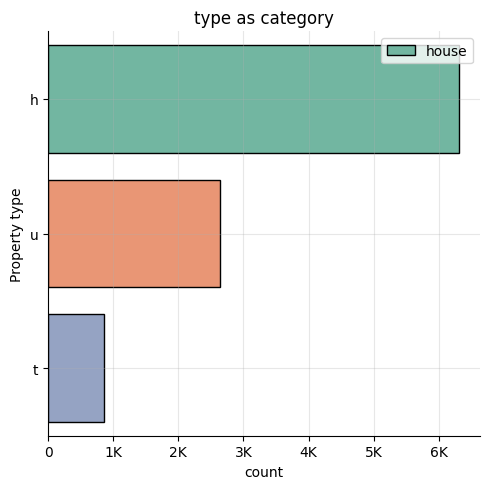

In [42]:
sns.catplot(data=df,
            y='Type',
            kind='count',
            palette=CATEGORICAL_PALETTE,
            edgecolor='black')

ax = plt.gca()

ax.figsize=FIGSIZE
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(FORMATTER)

plt.ylabel('Property type')
plt.title('type as category')
plt.legend(labels=['house', 'unit, duplex', 'townhouse'], loc=1)
plt.tight_layout()

In [43]:
df.size, df[df.YearBuilt.isna()].size

(176688, 68202)

In [44]:
def uniform_nan(data):
    if isinstance(data, str):
        data = data.strip()
    try:
        return int(data)
    except (ValueError, TypeError) as _:
        return np.nan

In [45]:
df.ZipCode = df.ZipCode.apply(uniform_nan)

In [46]:
for col in ['Bedroom2', 'Car', 'YearBuilt', 'Propertycount', 'ZipCode']:
    df[col] = df[col].astype(pd.Int64Dtype())

In [48]:
df[['Bedroom2', 'Car', 'YearBuilt', 'Propertycount']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9816 entries, 0 to 53628
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Bedroom2       9816 non-null   Int64
 1   Car            9762 non-null   Int64
 2   YearBuilt      6027 non-null   Int64
 3   Propertycount  9816 non-null   Int64
dtypes: Int64(4)
memory usage: 421.8 KB


### Eliminación de filas


Dado que se trata de un dataset pre-procesado por un usuario de kaggle según sus propios criterios:
- las columnas `Suburb`, `Rooms`, `Price`, `Type`, `Distance`, `Propertycount`, `Bedroom2`, `Car` se encuentran normalizadas y *limpias*,
- mientras que las entradas correspondientes a `Landsize`, `BuildingArea`, `YearBuilt` poseen datos faltantes e incorrectos
    - `Landsize` y `BuildingArea` deberían conservar una relación del tipo $Landsize > BuildingArea$. Se eliminaron aquellas filas que no lo cumplían, debido a que no se cuenta con información relacionada a estas dimensiones que permita estimarlos.

#### Landsize vs BuildingArea

Aquellas entradas donde $Landsize < BuildingArea$ *(no tiene sentido físico)*, se reflejan en `BuildingRatio < 1`

In [49]:
df.size, df[df.BuildingRatio < 1].size

(176688, 22554)

In [50]:
df = df[df.BuildingRatio >= 1]
df.size

70668

#### Rooms vs Bedrooms2

- La cantidad total de *habitaciones* no puede superar la *cantidad de dormitorios*

In [51]:
df[df.Rooms < df.Bedroom2].sample(15).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
5036,22 Champion St,Brighton,3,2M,h,11.2,10579,4,2,302.0,2000,Brighton,Bayside,VIC,3186,"Brighton, Australia",Very leafy very safe street 5 minute walk to 711 c,1.8
36,124 Yarra St,Abbotsford,3,2M,h,2.5,4019,4,0,210.0,1910,Richmond,Yarra,VIC,3067,"Abbotsford, Australia","Bridge Road (once famous for discount shopping, no",1.2
8404,12 Hamilton St,Brunswick West,2,820K,h,5.9,7082,3,1,98.0,1900,Brunswick,Moreland,VIC,3055,"Brunswick West, Australia",This hip area is a crossroads between two great cu,2.1
17951,1 Maitland St,Glen Iris,3,3M,h,9.2,10412,4,4,217.0,1910,Glen Iris,Boroondara,VIC,3146,"Glen Iris, Australia","Quiet, leafy, friendly & safe neighbourhood. Ample",4.1
23278,38 MacGregor St,Malvern East,3,2M,h,11.2,8801,4,1,196.0,1920,Malvern East,Stonnington,VIC,3145,"Malvern East, Australia",East Malvern is an established and well to do midd,3.9
5716,139 Thomas St,Brighton East,4,2M,h,10.7,6938,5,2,212.0,1948,Brighton,Bayside,VIC,3187,"Brighton East, Australia",Very leafy very safe street 5 minute walk to 711 c,2.8
1032,10 William St,Armadale,1,1M,h,6.3,4836,2,1,107.0,1900,Prahran,Stonnington,VIC,3143,"Armadale, Australia",Prahran is a great place to live. There are nice p,1.3
20740,9 Cook St,Ivanhoe,3,981K,h,7.9,5549,5,2,378.0,2016,Thornbury,Banyule,VIC,3079,"Ivanhoe, Australia","This is a great neighbourhood – it is quiet, yet c",1.7
22190,26 Queen St,Kew,3,2M,h,5.6,10331,4,1,139.0,1910,Kew,Boroondara,VIC,3101,"Kew, Australia","It is walking distance to the Kew Junction shops,",2.4
52875,44 Clive St,West Footscray,3,1M,h,8.2,5058,4,2,113.0,1925,Footscray,Maribyrnong,VIC,3012,"West Footscray, Australia",Seddon is a great place and growing by the minute,4.7


In [52]:
df = df[df.Rooms >= df.Bedroom2]
df.size

69534

### Tratamiento de datos faltantes

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3863 entries, 6 to 53619
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Address               3863 non-null   object  
 1   Suburb                3863 non-null   object  
 2   Rooms                 3863 non-null   int64   
 3   Price                 3863 non-null   float64 
 4   Type                  3863 non-null   category
 5   Distance              3863 non-null   float64 
 6   Propertycount         3863 non-null   Int64   
 7   Bedroom2              3863 non-null   Int64   
 8   Car                   3840 non-null   Int64   
 9   BuildingArea          3863 non-null   float64 
 10  YearBuilt             3732 non-null   Int64   
 11  Neighborhood          3863 non-null   object  
 12  City                  3863 non-null   object  
 13  State                 3863 non-null   object  
 14  ZipCode               3818 non-null   Int64   
 15  Sma

Se realiza el tratamiento de valores faltantes en las columnas `Car` e `YearBuilt`

In [54]:
df = df.where(pd.notnull(df), np.nan)

In [55]:
df[df.Car.isna() | df.YearBuilt.isna()].sample(20).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
21215,5 Rigby La,Kensington,3,845K,t,4.2,5263,3,1,105.0,missing,Flemington,Moonee Valley,VIC,3031,"Kensington, Australia",Flemington is an vibrant cosmopolitan yet historic,1.3
35721,672 Plenty Rd,Preston,5,630K,h,8.8,14577,5,3,5.0,missing,Thornbury,Darebin,VIC,3072,"Preston, Australia","This is a great neighbourhood – it is quiet, yet c",39.8
19156,10a Roydon St,Hampton East,3,1M,t,14.5,2356,2,2,171.0,missing,Brighton,Bayside,VIC,3188,"Hampton East, Australia",Very leafy very safe street 5 minute walk to 711 c,1.3
47578,43 Ballantyne St,Thornbury,2,925K,h,6.5,8870,2,1,157.0,missing,Thornbury,Darebin,VIC,3071,"Thornbury, Australia","This is a great neighbourhood – it is quiet, yet c",1.6
30035,11A Barbara St,Moorabbin,4,930K,h,14.6,2555,4,2,4.0,missing,Bentleigh,Kingston,VIC,3189,"Moorabbin, Australia",Oakleigh is a vibrant Greek community with lots of,110.8
52007,13 Pleasant Rd,Hawthorn East,4,2M,h,7.5,6482,4,2,278.0,missing,Hawthorn,Boroondara,VIC,3123,"Hawthorn East, Australia",Our house is perfectly located for you to enjoy an,2.6
2440,129 Gordon St,Balwyn,3,2M,h,9.7,5682,3,2,266.0,missing,Balwyn,Boroondara,VIC,3103,"Balwyn, Australia","Balwyn is a family suburb east of Melbourne, about",2.4
8175,1/208 Albion St,Brunswick,1,424K,u,5.2,11918,1,missing,80.0,2009,Brunswick,Moreland,VIC,3056,"Brunswick, Australia",This hip area is a crossroads between two great cu,4.2
16584,90 Edinburgh St,Flemington,3,1M,h,4.4,3593,2,1,20.0,missing,Flemington,Moonee Valley,VIC,3031,"Flemington, Australia",Flemington is an vibrant cosmopolitan yet historic,15.7
41949,303 Park St,South Melbourne,2,1M,h,1.9,5943,2,missing,79.0,missing,South Melbourne,Port Phillip,VIC,3205,"South Melbourne, Australia",Clarendon Street is a 5 minute walk and has someth,1.6


#### Car nan

- Se reemplazan los valores faltantes por **la media** de las entradas según:
    - pertenezcan al mismo **suburbio**
    - y al mismo **tipo** de propiedad

In [56]:
df.Car = df.groupby(['Suburb', 'Type']).fillna(method='ffill').Car

#### YearBuilt nan

- Se dejan en `nan` aquellos años numéricamente inválidos
- Se imputan en consignas posteriores

In [57]:
df.YearBuilt = df.YearBuilt.apply(uniform_nan)

In [58]:
df.sample(15).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
2148,93A Ashburn Gr,Ashburton,4,2M,t,10.2,3052,4,2,240.0,2013.0,Ashburton,Boroondara,VIC,3147,"Ashburton, Australia",Our local parks and gardens provide lovely walks a,2.1
37097,8 Bedwell St,Reservoir,4,750K,h,11.2,21650,4,4,197.0,1965.0,Coburg,Darebin,VIC,3073,"Reservoir, Australia",The apartment is fully self contained and separate,4.2
46844,17 Empress Rd,Surrey Hills,3,2M,h,11.2,5457,3,2,128.0,1910.0,Balwyn,Boroondara,VIC,3127,"Surrey Hills, Australia","Balwyn is a family suburb east of Melbourne, about",3.4
42395,12 Witchwood Cl,South Yarra,3,1M,t,3.3,14887,2,1,148.0,1990.0,Central Business District,Melbourne,VIC,3141,"South Yarra, Australia",The apartment is located in the centre of Melbourn,1.2
2432,2/16 Westminster St,Balwyn,2,1M,t,9.7,5682,2,1,129.0,2000.0,Balwyn,Boroondara,VIC,3103,"Balwyn, Australia","Balwyn is a family suburb east of Melbourne, about",1.6
37577,2/7 Colthur St,Reservoir,3,475K,u,11.2,21650,3,2,100.0,2010.0,Coburg,Darebin,VIC,3073,"Reservoir, Australia",The apartment is fully self contained and separate,5.2
35801,35 James St,Preston,4,810K,h,8.8,14577,4,2,151.0,1950.0,Thornbury,Darebin,VIC,3072,"Preston, Australia","This is a great neighbourhood – it is quiet, yet c",6.8
37547,13 Southernhay St,Reservoir,3,787K,h,11.2,21650,3,1,118.0,1940.0,Coburg,Darebin,VIC,3073,"Reservoir, Australia",The apartment is fully self contained and separate,4.8
4928,73 Martin St,Brighton,4,3M,h,11.2,10579,4,2,364.0,2000.0,Brighton,Bayside,VIC,3186,"Brighton, Australia",Very leafy very safe street 5 minute walk to 711 c,1.8
52563,21 Stewart St,Ormond,4,2M,h,11.8,3578,4,2,193.0,1935.0,Ormond/McKinnon,Glen Eira,VIC,3204,"Ormond, Australia",The best thing about my neighborhood is the fact t,3.6


In [59]:
df.columns

Index(['Address', 'Suburb', 'Rooms', 'Price', 'Type', 'Distance',
       'Propertycount', 'Bedroom2', 'Car', 'BuildingArea', 'YearBuilt',
       'Neighborhood', 'City', 'State', 'ZipCode', 'SmartLocation',
       'NeighborhoodOverview', 'BuildingRatio'],
      dtype='object')

### Outliers

In [60]:
df.describe().style.format(
    {col: human_format for col in df.columns},
    precision=2)

,Rooms,Price,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,ZipCode,BuildingRatio
count,4K,4K,4K,4K,4K,4K,4K,4K,4K,4K
mean,3,1M,8,8K,3,2,150,2K,3K,7
std,1,740K,3,4K,1,1,79,39,113,36
min,1,131K,0,394,0,0,1,2K,2K,1
25%,2,815K,6,5K,2,1,100,2K,3K,2
50%,3,1M,8,7K,3,2,130,2K,3K,3
75%,4,2M,11,10K,4,2,181,2K,3K,4
max,8,8M,16,22K,7,10,792,2K,3K,2K


In [61]:
df_desc = df.describe()
for col in df_desc.columns:
    print(f"{col}: ({human_format(df_desc[col].loc['min'])}, {human_format(df_desc[col].loc['max'])})")

Rooms: (1, 8)
Price: (131K, 8M)
Distance: (0, 16)
Propertycount: (394, 22K)
Bedroom2: (0, 7)
Car: (0, 10)
BuildingArea: (1, 792)
YearBuilt: (2K, 2K)
ZipCode: (2K, 3K)
BuildingRatio: (1, 2K)


Dado que el dataset en cuestión *ya está procesado*, mientras que algunos valores que se pudieron considerar potencialmente como outliers en las entradas de las columnas `Landsize` (como el cero), quedaron descartados durante la [eliminación de filas](#Eliminación-de-filas),
- se analizaron posibles outliers en la columna `Distance`
> Distance from CBD (Central Bussiness District)

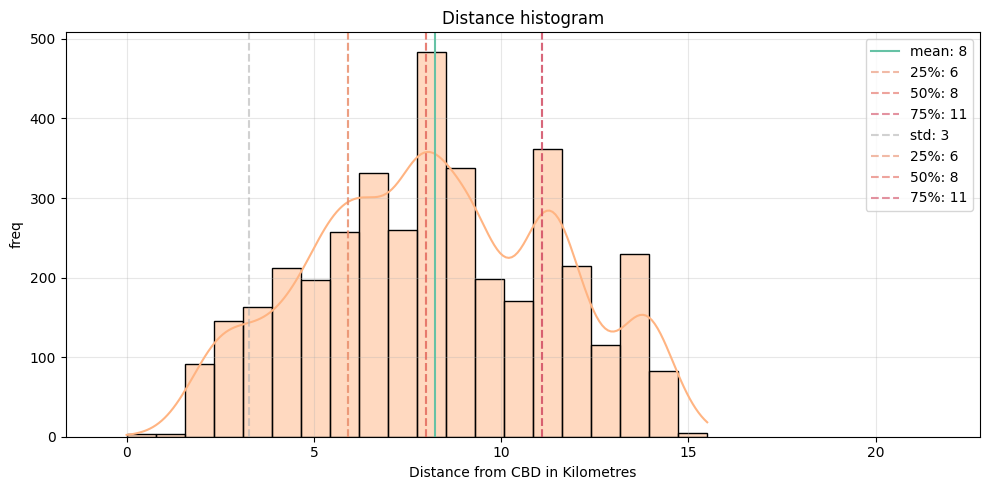

In [62]:
df_to_plot = df.Distance
x_label, y_label, title = 'Distance from CBD in Kilometres', 'freq', 'Distance histogram'
n_bins = 20

plot_hist(df_to_plot, x_label, y_label, title, n_bins)

> A central business district (CBD) is the commercial and business center of a city. It contains commercial space and offices, and in larger cities will often be described as a financial district. Geographically, it often coincides with the "city center" or "downtown", fuente: https://en.wikipedia.org/wiki/Central_business_district

De manera que las entradas con $Distance < 0.2 km$ *(que se consideraban a priori potenciales outliers)* cobra sentido físico en el caso de que la propiedad en cuestión se encuentre dentro de las delimitaciones del *"centro financiero"*, esto es:

**NO EXISTEN OUTLIERS**

### Exportación de datos

In [63]:
df.head()

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
6,25 Bloomburg St,Abbotsford,2,1035000.0,h,2.5,4019,2,0,79.0,1900.0,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...,1.974684
42,98 Charles St,Abbotsford,2,1636000.0,h,2.5,4019,2,2,107.0,1890.0,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...,2.392523
66,40 Nicholson St,Abbotsford,3,1350000.0,h,2.5,4019,3,2,190.0,2005.0,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...,1.126316
90,16 William St,Abbotsford,2,1310000.0,h,2.5,4019,2,2,97.0,1890.0,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...,2.453608
96,42 Henry St,Abbotsford,3,1200000.0,h,2.5,4019,3,1,110.0,1880.0,Richmond,Yarra,VIC,3067,"Abbotsford, Australia",Bridge Road (once famous for discount shopping...,1.027273


In [64]:
df.to_csv('data/melbourne_housing_curated_data.csv', index=False)